# Comparaison CAE vs VAE — Version Finale

**Corrections et améliorations :**
- Triple split strict 70/20/10
- Normalisation calculée sur X_train uniquement (pas de data leakage)
- VAE avec `test_step` → EarlyStopping sur `val_loss`
- Segment de reconstruction extrait AVANT le shuffle (signal continu réel)
- Reconstruction et génération affichées sur les 3 axes
- Inférence VAE cohérente avec l'entraînement (z échantillonné)
- Analyse spectrale (Welch PSD) pour valider la cohérence physiologique

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from scipy.signal import welch
import time

## 1. Chargement et fenêtrage

In [7]:
path = "D:/IMDS/MALMO/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet"
df = pd.read_parquet(path)

print(df["global_activity_label"].unique())

features = ["acc_x", "acc_y", "acc_z"]
df = df[["timestamp_ns", "dataset", "subject_id", "session_id", "global_activity_id"] + features]

# Passage à 25Hz
df = df.iloc[::2].copy()
df[features] = df[features].interpolate(method='linear').bfill().ffill()

WINDOW_SIZE = 50
STRIDE      = 25
N_WINDOWS   = 30
FS          = 25    # fréquence d'échantillonnage en Hz

TARGET_LABEL = 1
LABEL_NAME   = "Marche"
axis_names   = ["acc_x", "acc_y", "acc_z"]

# Extraction du segment continu AVANT le shuffle
segment_continu = None

for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig  = group.sort_values("timestamp_ns")[features].values
    acts = group.sort_values("timestamp_ns")["global_activity_id"].values

    wins, win_labels = [], []
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        lbl = np.bincount(acts[i:i + WINDOW_SIZE]).argmax()
        wins.append(sig[i:i + WINDOW_SIZE])
        win_labels.append(lbl)

    wins       = np.array(wins, dtype=np.float32)
    win_labels = np.array(win_labels)

    count, start = 0, 0
    for idx in range(len(win_labels)):
        if win_labels[idx] == TARGET_LABEL:
            if count == 0:
                start = idx
            count += 1
            if count >= N_WINDOWS:
                segment_continu = wins[start:start + N_WINDOWS]
                break
        else:
            count = 0
    if segment_continu is not None:
        break

if segment_continu is None:
    raise ValueError(f"Pas assez de fenêtres consécutives pour le label {TARGET_LABEL}.")

print(f"Segment continu '{LABEL_NAME}' trouvé : {segment_continu.shape}")

X, labels = [], []
print("Création des fenêtres d'entraînement...")
for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig  = group.sort_values("timestamp_ns")[features].values
    acts = group.sort_values("timestamp_ns")["global_activity_id"].values
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        X.append(sig[i:i + WINDOW_SIZE])
        labels.append(np.bincount(acts[i:i + WINDOW_SIZE]).argmax())

X      = np.array(X, dtype=np.float32)
labels = np.array(labels)
print(f"Dataset complet : {X.shape}  —  {len(np.unique(labels))} labels uniques")

<ArrowStringArray>
['posture_stationary', 'walk', 'rest_inactive']
Length: 3, dtype: string
Segment continu 'Marche' trouvé : (30, 50, 3)
Création des fenêtres d'entraînement...
Dataset complet : (211039, 50, 3)  —  3 labels uniques


## 2. Triple split 70 / 20 / 10 + normalisation sans data leakage

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, labels, test_size=0.10, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp
)

# Normalisation calculée UNIQUEMENT sur X_train
X_mean = np.mean(X_train, axis=(0, 1))
X_std  = np.std(X_train,  axis=(0, 1))

X_train         = (X_train         - X_mean) / (X_std + 1e-7)
X_val           = (X_val           - X_mean) / (X_std + 1e-7)
X_test          = (X_test          - X_mean) / (X_std + 1e-7)
segment_continu = (segment_continu - X_mean) / (X_std + 1e-7)

print(f"Train : {len(X_train):>7} fenêtres")
print(f"Val   : {len(X_val):>7} fenêtres")
print(f"Test  : {len(X_test):>7} fenêtres")

Train :  147731 fenêtres
Val   :   42204 fenêtres
Test  :   21104 fenêtres


## 3. Architectures

In [7]:
timesteps  = 50
n_features = 3
latent_dim = 32
EPOCHS     = 150
BATCH_SIZE = 256
PATIENCE   = 8

def get_encoder_cae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(latent_dim, name="cae_latent")(x)
    return Model(inputs, latent, name="Encoder_CAE")

def get_encoder_vae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    return Model(inputs, [z_mean, z_log_var], name="Encoder_VAE")

def get_decoder(name):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(12 * 128, activation='relu')(inputs)
    x = layers.Reshape((12, 128))(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.ZeroPadding1D(padding=(1, 1))(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)
    return Model(inputs, outputs, name=name)

## 4. Entraînement CAE

In [8]:
print("--- ENTRAÎNEMENT CAE ---")
cae_encoder = get_encoder_cae()
cae_decoder = get_decoder("Decoder_CAE")
cae_model   = Model(cae_encoder.input, cae_decoder(cae_encoder.output))
cae_model.compile(optimizer='adam', loss='mse')

t0 = time.time()
history_cae = cae_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_cae = time.time() - t0
print(f"CAE entraîné en {time_cae:.1f}s")

--- ENTRAÎNEMENT CAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1069 - val_loss: 0.0664
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0555 - val_loss: 0.0515
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0498 - val_loss: 0.0497
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0486 - val_loss: 0.0496
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0473 - val_loss: 0.0467
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0462 - val_loss: 0.0456
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0455 - val_loss: 0.0453
Epoch 8/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0450 - val_loss: 0.0466
Epoch 9/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0440 - val_loss: 0.0453
Epoch 10/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0428 - val_loss: 0.0490
Epoch 11/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0427 - val_loss: 0.0425
Epoch

## 5. Entraînement VAE

In [9]:
class BetaVAE(Model):
    def __init__(self, encoder, decoder, beta=0.01, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_loss(self, data):
        zm, zv = self.encoder(data)
        z      = zm + 0.1 * tf.exp(0.5 * zv) * tf.random.normal(tf.shape(zm))
        recon  = self.decoder(z)
        r_loss  = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(data, recon), axis=-1))
        kl_loss = -0.5 * tf.reduce_mean(1 + zv - tf.square(zm) - tf.exp(zv))
        return r_loss + self.beta * kl_loss, r_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total, r_loss, kl_loss = self._compute_loss(data)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        total, r_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


print("--- ENTRAÎNEMENT VAE ---")
vae_enc   = get_encoder_vae()
vae_dec   = get_decoder("Decoder_VAE")
vae_model = BetaVAE(vae_enc, vae_dec, beta=0.01)
vae_model.compile(optimizer=tf.keras.optimizers.Adam())

t0 = time.time()
history_vae = vae_model.fit(
    X_train,
    validation_data=(X_val,),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_vae = time.time() - t0
print(f"VAE entraîné en {time_vae:.1f}s")

--- ENTRAÎNEMENT VAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - kl: 1.8652 - loss: 4.9831 - recon: 4.9645 - val_kl: 2.0800 - val_loss: 3.0431 - val_recon: 3.0223
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - kl: 2.1285 - loss: 2.7809 - recon: 2.7596 - val_kl: 2.1623 - val_loss: 2.5700 - val_recon: 2.5483
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - kl: 2.1388 - loss: 2.5303 - recon: 2.5089 - val_kl: 2.1453 - val_loss: 2.4625 - val_recon: 2.4411
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - kl: 2.0961 - loss: 2.4477 - recon: 2.4267 - val_kl: 2.0861 - val_loss: 2.3936 - val_recon: 2.3727
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - kl: 2.0582 - loss: 2.3924 - recon: 2.3718 - val_kl: 2.0001 - val_loss: 2.3379 - val_recon: 2.3179
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - kl: 2.0101 - loss: 2.3319 - recon: 2.3118 - val_kl: 1.9406 - val_loss: 2.3708 - val_recon: 2.3514
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/s

## 6. Courbes d'apprentissage

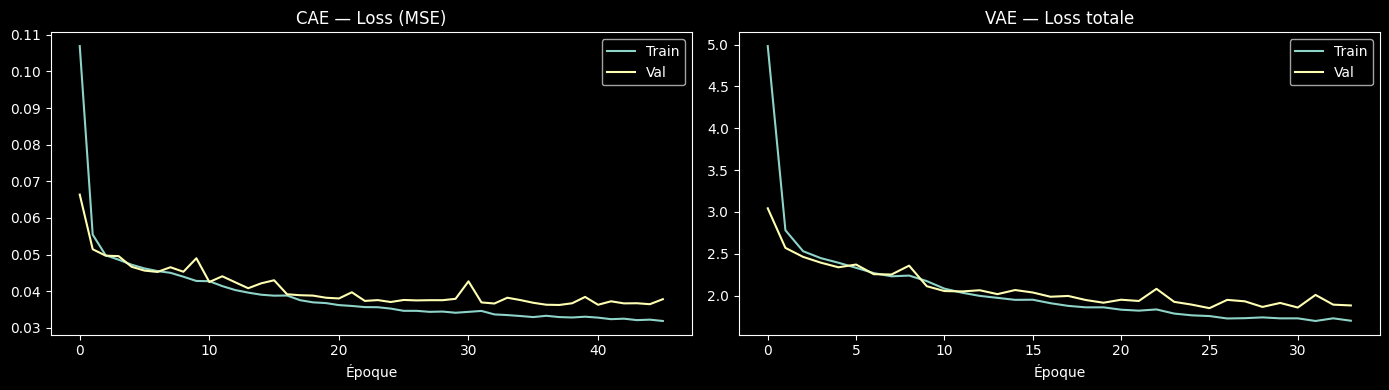

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cae.history['loss'],     label='Train')
axes[0].plot(history_cae.history['val_loss'], label='Val')
axes[0].set_title("CAE — Loss (MSE)")
axes[0].set_xlabel("Époque")
axes[0].legend()

axes[1].plot(history_vae.history['loss'],     label='Train')
axes[1].plot(history_vae.history['val_loss'], label='Val')
axes[1].set_title("VAE — Loss totale")
axes[1].set_xlabel("Époque")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluation finale sur le test set

In [11]:
mse_cae = cae_model.evaluate(X_test, X_test, verbose=0)

zm_test, zv_test = vae_enc.predict(X_test, verbose=0)
z_test           = zm_test + 0.1 * np.exp(0.5 * zv_test) * np.random.normal(size=zm_test.shape)
recon_vae_test   = vae_dec.predict(z_test.astype(np.float32), verbose=0)
mse_vae          = np.mean(np.square(X_test - recon_vae_test))

print("=" * 48)
print(f"RÉSULTATS FINAUX  (Test set : {len(X_test)} fenêtres)")
print("=" * 48)
print(f"CAE  →  Temps : {time_cae:.1f}s  |  MSE test : {mse_cae:.6f}")
print(f"VAE  →  Temps : {time_vae:.1f}s  |  MSE test : {mse_vae:.6f}")

RÉSULTATS FINAUX  (Test set : 21104 fenêtres)
CAE  →  Temps : 329.8s  |  MSE test : 0.037365
VAE  →  Temps : 261.5s  |  MSE test : 0.037779


## 8. t-SNE sur l'espace latent (test set)

Calcul t-SNE...


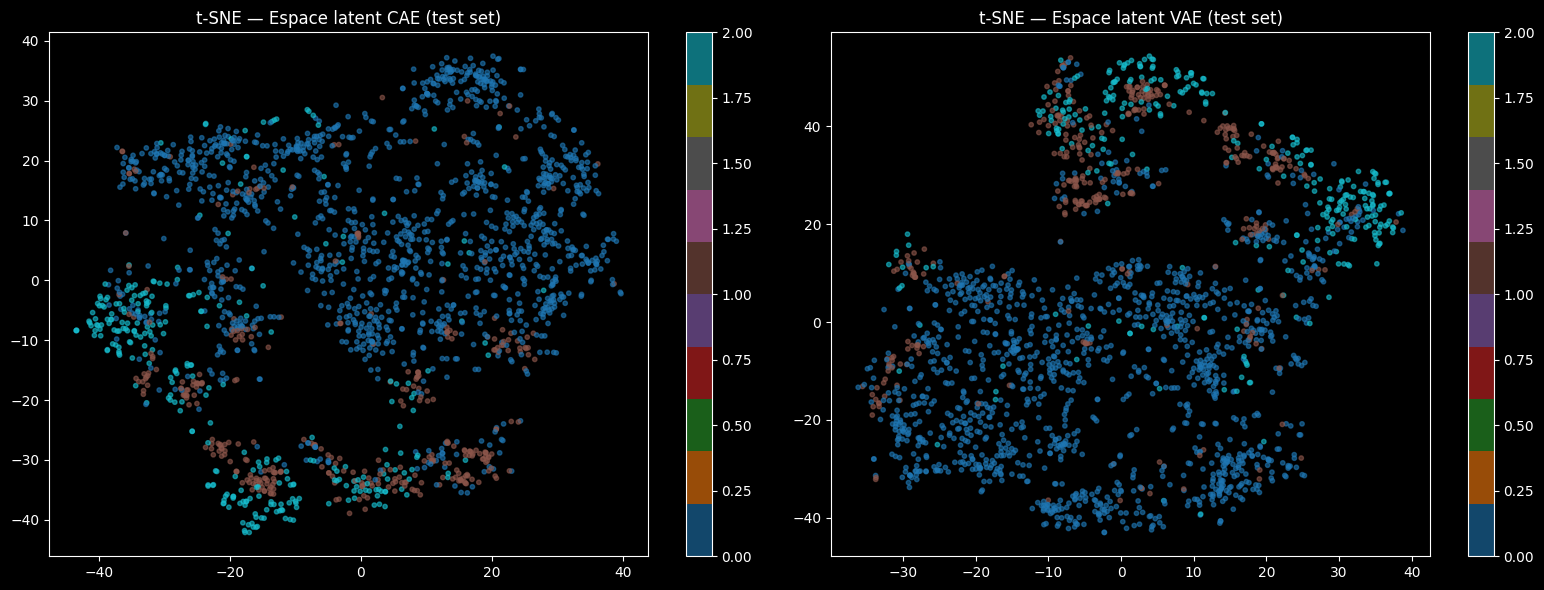

In [12]:
print("Calcul t-SNE...")
n_tsne = min(2000, len(X_test))

lat_cae    = cae_encoder.predict(X_test[:n_tsne], verbose=0)
lat_vae, _ = vae_enc.predict(X_test[:n_tsne], verbose=0)

tsne    = TSNE(n_components=2, random_state=42, perplexity=30)
emb_cae = tsne.fit_transform(lat_cae)
emb_vae = tsne.fit_transform(lat_vae)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sc1 = ax1.scatter(emb_cae[:, 0], emb_cae[:, 1], c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax1.set_title("t-SNE — Espace latent CAE (test set)")
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(emb_vae[:, 0], emb_vae[:, 1], c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax2.set_title("t-SNE — Espace latent VAE (test set)")
plt.colorbar(sc2, ax=ax2)

plt.tight_layout()
plt.show()

## 9. Reconstruction cohérente — 1 minute d'une seule activité

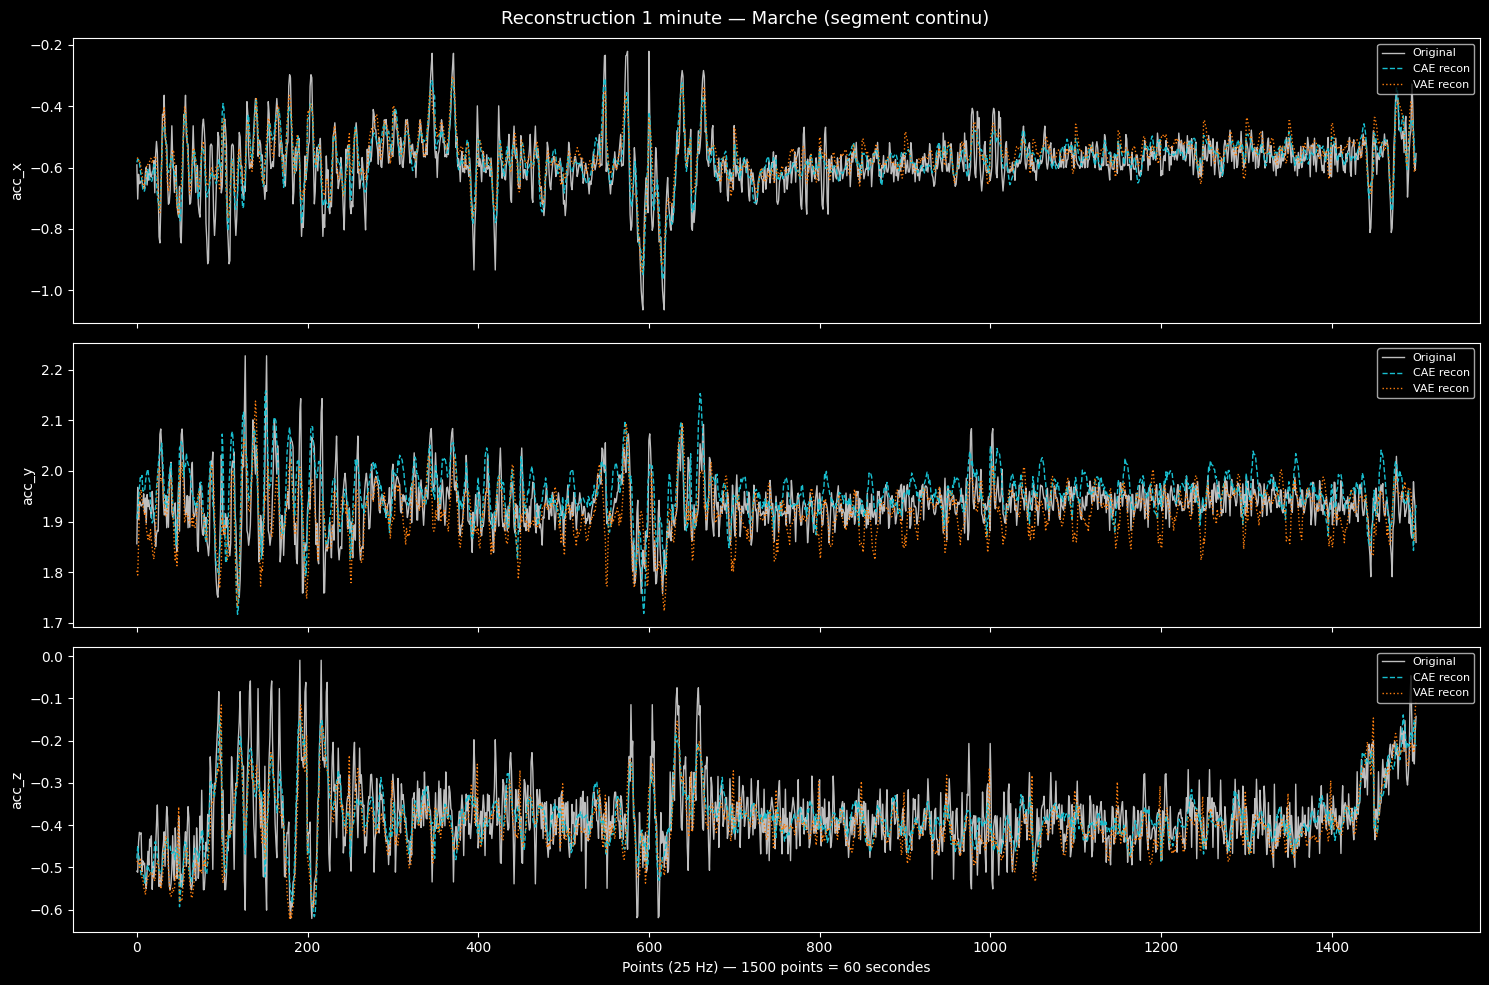

In [13]:
recon_cae_seg = cae_model.predict(segment_continu, verbose=0)

zm_seg, zv_seg = vae_enc.predict(segment_continu, verbose=0)
z_seg          = zm_seg + 0.1 * np.exp(0.5 * zv_seg) * np.random.normal(size=zm_seg.shape)
recon_vae_seg  = vae_dec.predict(z_seg.astype(np.float32), verbose=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Reconstruction 1 minute — {LABEL_NAME} (segment continu)", fontsize=13)

for j, ax in enumerate(axes):
    orig  = segment_continu[:, :, j].flatten()
    r_cae = recon_cae_seg[:, :, j].flatten()
    r_vae = recon_vae_seg[:, :, j].flatten()

    ax.plot(orig,  label="Original",  color='white',      alpha=0.75, linewidth=1)
    ax.plot(r_cae, label="CAE recon", color='tab:cyan',   linestyle='--', linewidth=1)
    ax.plot(r_vae, label="VAE recon", color='tab:orange', linestyle=':',  linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz) — 1500 points = 60 secondes")
plt.tight_layout()
plt.show()

## 10. Génération synthétique VAE — 1 minute de signal pur

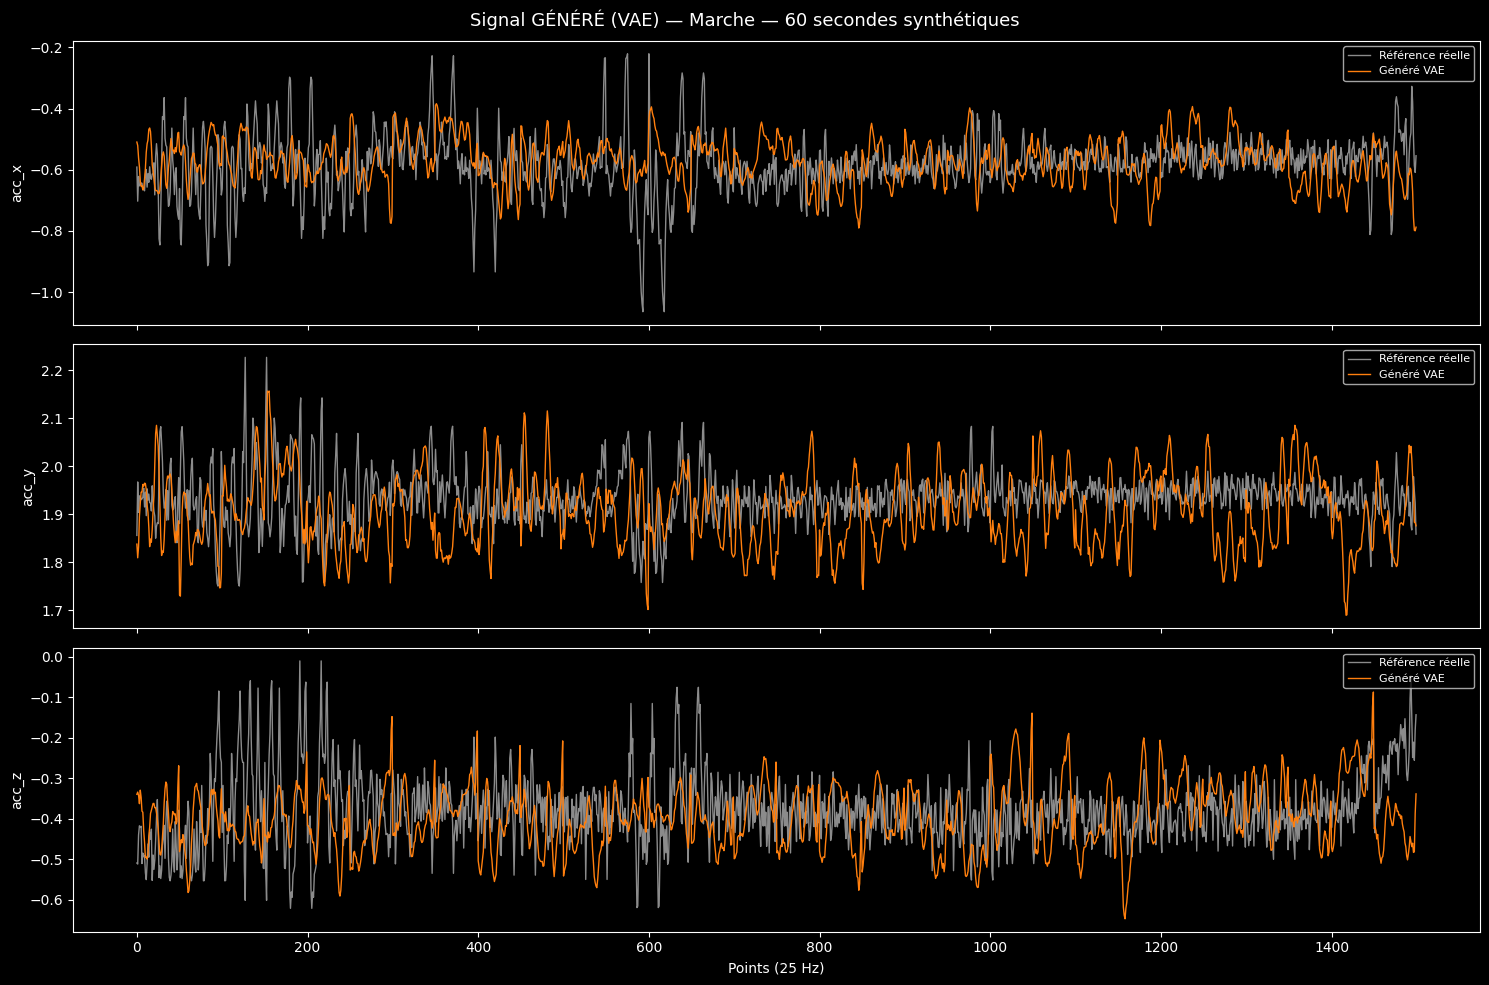

In [14]:
zm_label, _ = vae_enc.predict(segment_continu, verbose=0)
z_centre     = np.mean(zm_label, axis=0)
z_std_label  = np.std(zm_label,  axis=0)

z_generated   = np.random.normal(
    loc=z_centre, scale=z_std_label, size=(N_WINDOWS, latent_dim)
).astype(np.float32)

signal_genere = vae_dec.predict(z_generated, verbose=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Signal GÉNÉRÉ (VAE) — {LABEL_NAME} — 60 secondes synthétiques", fontsize=13)

for j, ax in enumerate(axes):
    orig = segment_continu[:, :, j].flatten()
    gen  = signal_genere[:, :, j].flatten()

    ax.plot(orig, label="Référence réelle", color='white',      alpha=0.55, linewidth=1)
    ax.plot(gen,  label="Généré VAE",       color='tab:orange', linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz)")
plt.tight_layout()
plt.show()

## 11. Analyse spectrale (Welch PSD) — Réel vs Généré VAE

On utilise la méthode de Welch (Power Spectral Density) plutôt qu'un spectrogramme
classique car nos signaux sont courts (1500 points). Welch divise le signal en
segments avec overlap et moyenne les spectres — beaucoup plus stable sur des
signaux courts.

Ce qu'on s'attend à voir pour la marche à 25Hz :
- **acc_x** (balancement main) : pic principal vers 1-2 Hz (fréquence de pas),
  harmoniques à 2-4 Hz
- **acc_y** (montée/descente corps) : pic vers 1-2 Hz mais à la moitié de la
  fréquence de pas (le corps monte/descend une fois pour deux pas)
- **acc_z** (latéral) : peu d'énergie si marche en ligne droite, signal quasi plat

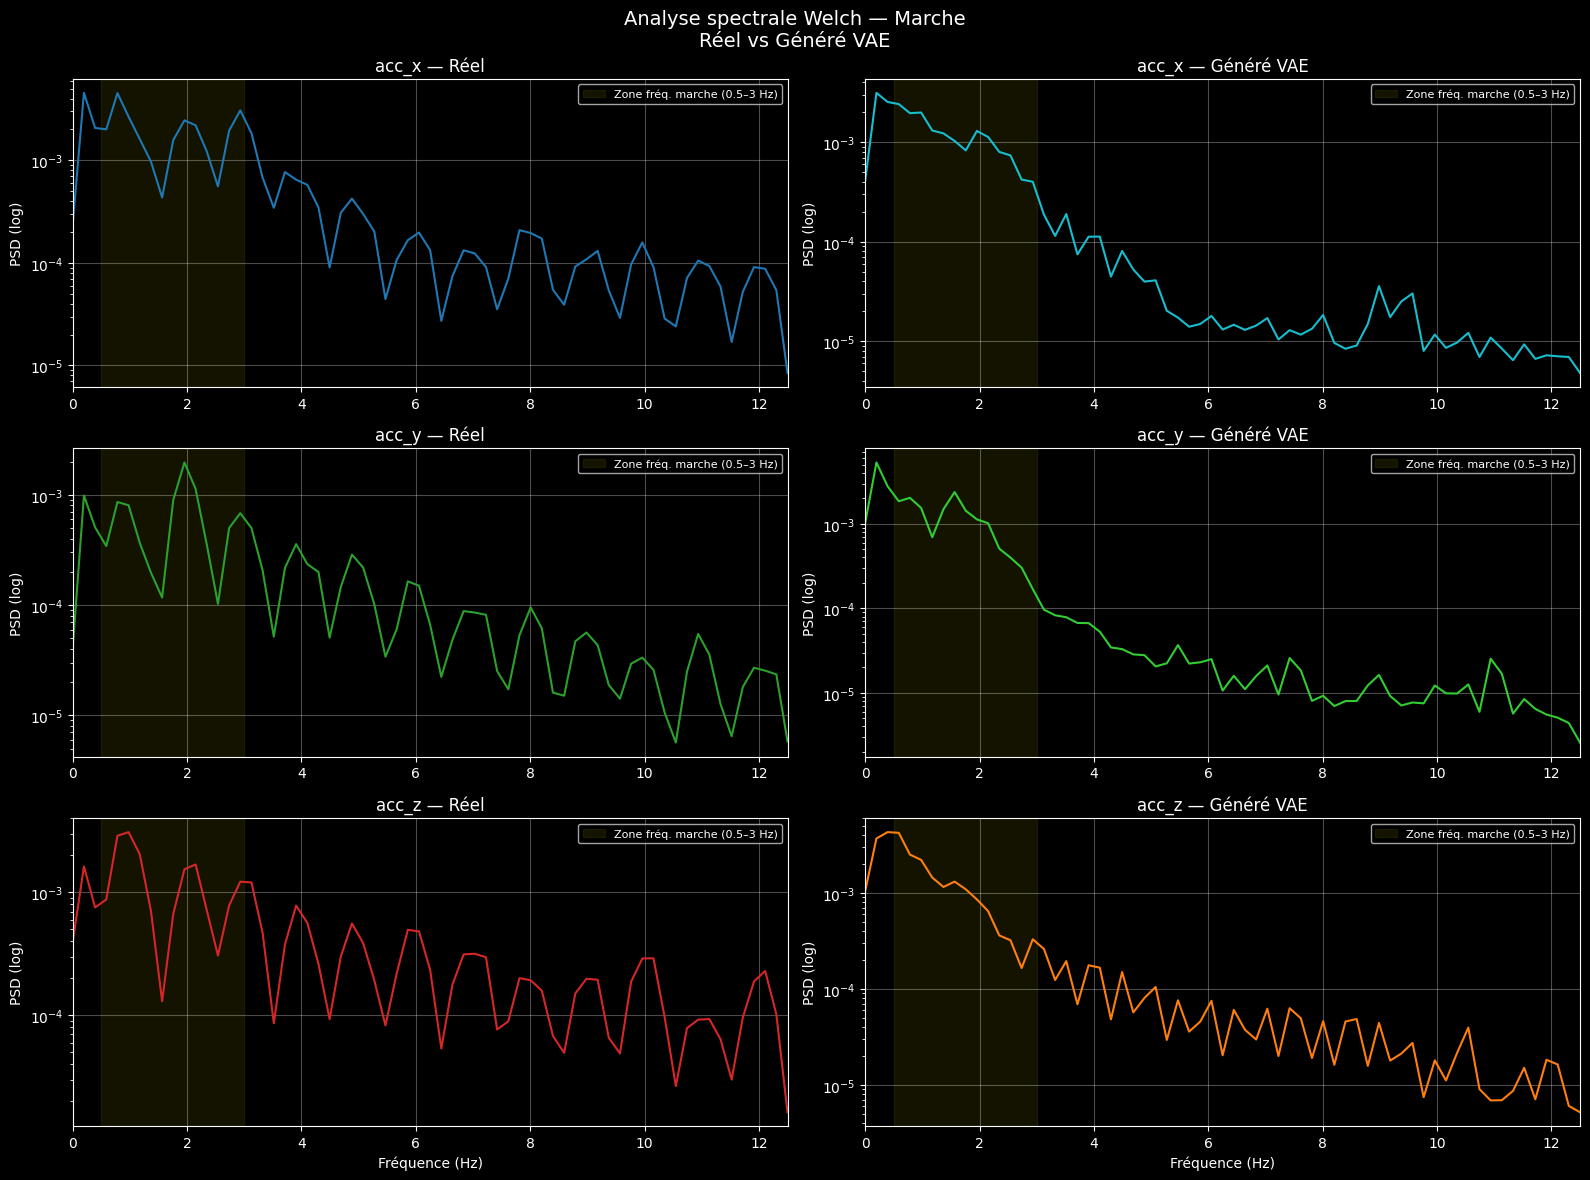

In [15]:
# Aplatir les segments en signaux continus (1500 points)
sig_reel = segment_continu[:, :, :]   # (30, 50, 3)
sig_gen  = signal_genere              # (30, 50, 3)

# Paramètres Welch
# nperseg = 128 points → résolution fréquentielle = 25/128 ≈ 0.2 Hz
# suffisant pour distinguer les pics de marche (~1-2 Hz)
NPERSEG = 128

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f"Analyse spectrale Welch — {LABEL_NAME}\nRéel vs Généré VAE", fontsize=14)

colors_reel = ['tab:blue',  'tab:green', 'tab:red']
colors_gen  = ['tab:cyan',  'limegreen',  'tab:orange']

for j in range(3):
    # Signal continu de chaque axe
    s_reel = sig_reel[:, :, j].flatten()   # (1500,)
    s_gen  = sig_gen[:, :, j].flatten()    # (1500,)

    # Welch PSD
    f_reel, psd_reel = welch(s_reel, fs=FS, nperseg=NPERSEG)
    f_gen,  psd_gen  = welch(s_gen,  fs=FS, nperseg=NPERSEG)

    # --- Colonne gauche : signal réel ---
    ax_reel = axes[j, 0]
    ax_reel.semilogy(f_reel, psd_reel, color=colors_reel[j], linewidth=1.5)
    ax_reel.set_ylabel("PSD (log)")
    ax_reel.set_title(f"{axis_names[j]} — Réel")
    ax_reel.set_xlim(0, FS / 2)   # 0 → 12.5 Hz (Nyquist)
    ax_reel.axvspan(0.5, 3.0, alpha=0.08, color='yellow',
                    label="Zone fréq. marche (0.5–3 Hz)")
    ax_reel.legend(fontsize=8)
    ax_reel.grid(True, alpha=0.3)

    # --- Colonne droite : signal généré VAE ---
    ax_gen = axes[j, 1]
    ax_gen.semilogy(f_gen, psd_gen, color=colors_gen[j], linewidth=1.5)
    ax_gen.set_ylabel("PSD (log)")
    ax_gen.set_title(f"{axis_names[j]} — Généré VAE")
    ax_gen.set_xlim(0, FS / 2)
    ax_gen.axvspan(0.5, 3.0, alpha=0.08, color='yellow',
                   label="Zone fréq. marche (0.5–3 Hz)")
    ax_gen.legend(fontsize=8)
    ax_gen.grid(True, alpha=0.3)

# Axe x commun en bas
for ax in axes[2, :]:
    ax.set_xlabel("Fréquence (Hz)")

plt.tight_layout()
plt.show()

## 12. Analyse spectrale — Superposition réel / généré par axe

Même analyse mais superposée sur un seul graphique par axe pour comparer
directement les deux distributions fréquentielles.

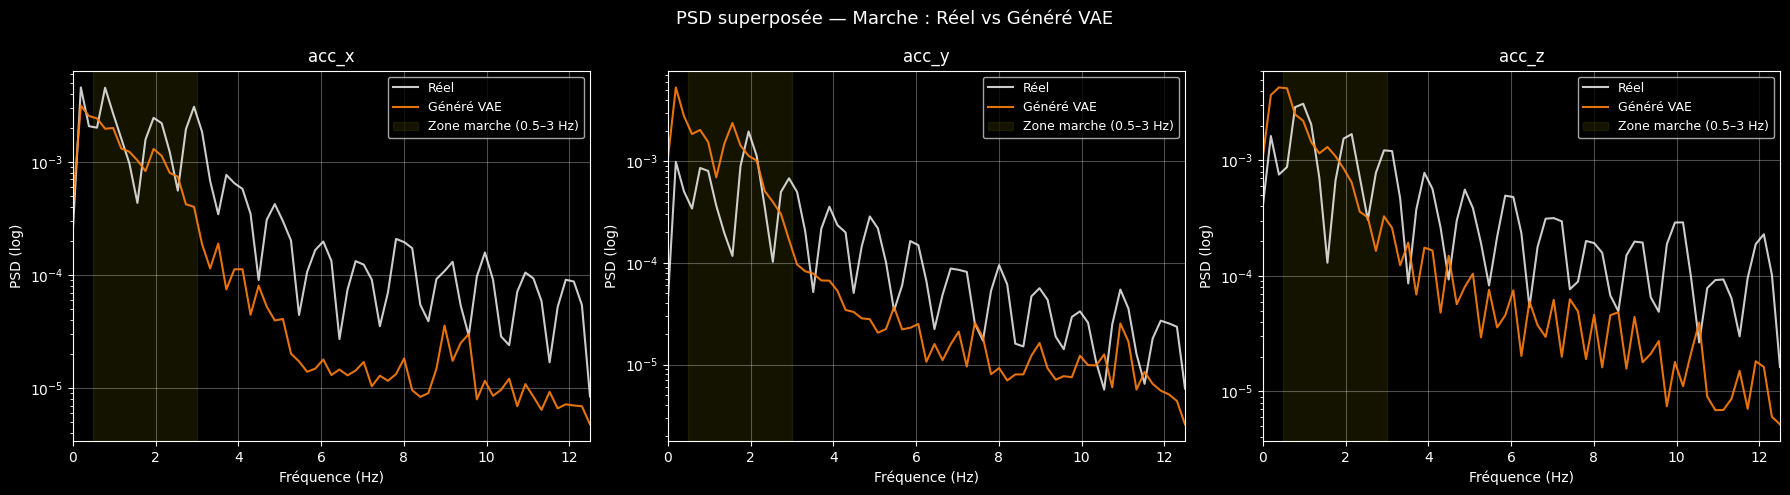

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"PSD superposée — {LABEL_NAME} : Réel vs Généré VAE", fontsize=13)

for j, ax in enumerate(axes):
    s_reel = sig_reel[:, :, j].flatten()
    s_gen  = sig_gen[:, :, j].flatten()

    f_reel, psd_reel = welch(s_reel, fs=FS, nperseg=NPERSEG)
    f_gen,  psd_gen  = welch(s_gen,  fs=FS, nperseg=NPERSEG)

    ax.semilogy(f_reel, psd_reel, color='white',      linewidth=1.5, label="Réel",        alpha=0.8)
    ax.semilogy(f_gen,  psd_gen,  color='tab:orange', linewidth=1.5, label="Généré VAE",  alpha=0.9)
    ax.axvspan(0.5, 3.0, alpha=0.08, color='yellow', label="Zone marche (0.5–3 Hz)")

    ax.set_title(axis_names[j])
    ax.set_xlabel("Fréquence (Hz)")
    ax.set_ylabel("PSD (log)")
    ax.set_xlim(0, FS / 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()